# DS 4320 Project 1 - Pipeline

## Breaking the Filter Bubble: A Diversity Aware Movie Recommendation System

### 1) Loading the four table relational database into DuckDB

Setting up Imports, Logging, and Configuration:

In [1]:
# Importing necessary libraries:
import logging # Importing logging
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import duckdb
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Setting up Logging: writes to both console and log file in 'logs/pipeline.log'
os.makedirs('logs', exist_ok=True)
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[
        logging.FileHandler('logs/pipeline.log'),
        logging.StreamHandler(sys.stdout)
    ]
)
log = logging.getLogger(__name__)

#  Configuration:
DATA_DIR = '../data/'
GENRE_COLS = [
    'Action','Adventure','Animation','Childrens','Comedy','Crime',
    'Documentary','Drama','Fantasy','Film_Noir','Horror','Musical',
    'Mystery','Romance','Sci_Fi','Thriller','War','Western'
]
N_CYCLES   = 25   # recommendation sessions to simulate
TOP_N      = 10   # items per recommendation list
N_NEIGHBORS = 20  # CF neighbors per user
TARGET_USERS = list(range(1, 51))  # 100 users to simulate

log.info("Setup complete.")


2026-03-31 20:10:12,455 | INFO | Setup complete.


## Step 1: Loading Data into DuckDB

The four .csv files are saved into DuckDB's in memory instance. 

In [2]:
# Using try and except for error handling:
try:
    con = duckdb.connect()  # in-memory DuckDB instance
    for table, fname in [('ratings','ratings.csv'), ('movies','movies.csv'),
                         ('users','users.csv'), ('genres','genres.csv')]:
        # Create the table for each CSV file:
        con.execute(f"CREATE TABLE {table} AS SELECT * FROM read_csv_auto('{DATA_DIR}{fname}')")
        log.info(f"Loaded table '{table}' from {fname}")
    log.info("All 4 tables loaded into DuckDB.") # Completion message
    # ── MovieLens 1M tables ───────────────────────────────────────────────────
    for table, fname in [('ratings_1m','ratings_1m.csv'), ('movies_1m','movies_1m.csv'),
                         ('users_1m','users_1m.csv')]:
        con.execute(f"CREATE TABLE {table} AS SELECT * FROM read_csv_auto('{DATA_DIR}{fname}')")
        log.info(f"Loaded 1M table '{table}'")
    log.info("All 7 tables loaded into DuckDB.")
except Exception as e:
    log.error(f"DuckDB load error: {e}")
    raise


2026-03-31 20:10:12,567 | INFO | Loaded table 'ratings' from ratings.csv
2026-03-31 20:10:12,589 | INFO | Loaded table 'movies' from movies.csv
2026-03-31 20:10:12,597 | INFO | Loaded table 'users' from users.csv
2026-03-31 20:10:12,598 | INFO | Loaded table 'genres' from genres.csv
2026-03-31 20:10:12,598 | INFO | All 4 tables loaded into DuckDB.
2026-03-31 20:10:12,673 | INFO | Loaded 1M table 'ratings_1m'
2026-03-31 20:10:12,695 | INFO | Loaded 1M table 'movies_1m'
2026-03-31 20:10:12,708 | INFO | Loaded 1M table 'users_1m'
2026-03-31 20:10:12,709 | INFO | All 7 tables loaded into DuckDB.


## Step 2: SQL Queries - EDA

In [3]:
# 1st Query: Finding the top 10 most rated movies:
try:
    # Selecting the 4 columns and calculating the number of ratings
    # and average rating for each movie:
    top_movies = con.execute("""
        SELECT m.movieId,
               m.title,
               COUNT(r.rating)       AS num_ratings,
               ROUND(AVG(r.rating), 2) AS avg_rating
        FROM   ratings r
        JOIN   movies  m ON r.movieId = m.movieId
        GROUP  BY m.movieId, m.title
        ORDER  BY num_ratings DESC
        LIMIT  10
    """).df()
    log.info("Query 1 (top movies) complete.")
    print("Top 10 Most-Rated Movies:")
    display(top_movies)
except Exception as e:
    log.error(f"Query 1 failed: {e}")
    raise

2026-03-31 20:10:12,727 | INFO | Query 1 (top movies) complete.
Top 10 Most-Rated Movies:


,movieId,title,num_ratings,avg_rating
0,50,Star Wars (1977),583,4.36
1,258,Contact (1997),509,3.80
2,100,Fargo (1996),508,4.16
3,181,Return of the Jedi (1983),507,4.01
4,294,Liar Liar (1997),485,3.16
5,286,"English Patient, The (1996)",481,3.66
6,288,Scream (1996),478,3.44
7,1,Toy Story (1995),452,3.88
8,300,Air Force One (1997),431,3.63
9,121,Independence Day (ID4) (1996),429,3.44


In [4]:
# 2nd Query: Lookinga at Genre Popularity

# Counts how many movies belong to each genre using the binary flag columns. 
# This query helps understand genre distribution in the dataset and help interpret
# ILD Results

try:
    genre_rows = []
    for g in GENRE_COLS:
        # Counting how many movies have the genre flag set to 1 for each genre column
        count = con.execute(f'SELECT COUNT(*) FROM movies WHERE "{g}" = 1').fetchone()[0]
        genre_rows.append({'genre': g, 'movie_count': count}) # appending the genre and its count to the list
    genre_counts = pd.DataFrame(genre_rows).sort_values('movie_count', ascending=False)
    log.info("Query 2 (genre counts) complete.")
    print("Movies per Genre:")
    display(genre_counts)
except Exception as e:
    log.error(f"Query 2 failed: {e}")
    raise


2026-03-31 20:10:12,761 | INFO | Query 2 (genre counts) complete.
Movies per Genre:


,genre,movie_count
7,Drama,725
4,Comedy,505
0,Action,251
15,Thriller,251
13,Romance,247
1,Adventure,135
3,Childrens,122
5,Crime,109
14,Sci_Fi,101
10,Horror,92


In [5]:
# 3rd Query: User Activity Distribution

# Identifies how many ratings each user has submitted, helps understand how
# active users produce more stable CF similarity estimates

try:
    user_activity = con.execute("""
        SELECT userId,
               COUNT(*)            AS num_ratings,
               ROUND(AVG(rating), 2) AS avg_rating
        FROM   ratings
        GROUP  BY userId
        ORDER  BY num_ratings DESC
    """).df()
    log.info("Query 3 (user activity) complete.")
    print(f"User activity: min={user_activity.num_ratings.min()}, "
          f"max={user_activity.num_ratings.max()}, "
          f"mean={user_activity.num_ratings.mean():.1f}")
    display(user_activity.head(10))
except Exception as e:
    log.error(f"Query 3 failed: {e}")
    raise


2026-03-31 20:10:12,772 | INFO | Query 3 (user activity) complete.
User activity: min=20, max=737, mean=106.0


,userId,num_ratings,avg_rating
0,405,737,1.83
1,655,685,2.91
2,13,636,3.10
3,450,540,3.86
4,276,518,3.47
5,416,493,3.85
6,537,490,2.87
7,303,484,3.37
8,234,480,3.12
9,393,448,3.34


In [6]:
# Query 4: Cross-dataset comparison (100K vs 1M)
try:
    comparison = con.execute("""
        SELECT '100K' AS dataset,
               COUNT(*) AS total_ratings,
               COUNT(DISTINCT userId) AS unique_users,
               COUNT(DISTINCT movieId) AS unique_movies,
               ROUND(AVG(rating), 3) AS avg_rating
        FROM ratings
        UNION ALL
        SELECT '1M', COUNT(*), COUNT(DISTINCT userId),
               COUNT(DISTINCT movieId), ROUND(AVG(rating), 3)
        FROM ratings_1m
    """).df()
    log.info("Query 4 (cross-dataset comparison) complete.")
    display(comparison)
except Exception as e:
    log.error(f"Query 4 failed: {e}")
    raise

2026-03-31 20:10:12,786 | INFO | Query 4 (cross-dataset comparison) complete.


,dataset,total_ratings,unique_users,unique_movies,avg_rating
0,100K,100000,943,1682,3.530
1,1M,1000209,6040,3706,3.582


## Step 3: Load Tables into Pandas for ML Pipeline

In [7]:
try:
    ratings = con.execute("SELECT * FROM ratings").df()
    movies  = con.execute("SELECT * FROM movies").df()
    users   = con.execute("SELECT * FROM users").df()
    movies_indexed = movies.set_index('movieId')  # fast lookup by movieId
    log.info(f"Loaded: ratings={ratings.shape}, movies={movies.shape}, users={users.shape}")
except Exception as e:
    log.error(f"Pandas load failed: {e}")
    raise


2026-03-31 20:10:12,795 | INFO | Loaded: ratings=(100000, 4), movies=(1682, 21), users=(943, 5)


## Step 4: Collaborative Filtering and Diversity Functions

In [8]:
# First function: build_user_item_matrix
# This function creates a user-item matrix from the ratings DataFrame, where rows represent users and columns represent movies. 
# The values in the matrix are the ratings given by users to movies. If a user has not rated a movie, the corresponding cell is filled with 0. 
# This is a common approach in collaborative filtering to handle missing ratings when calculating similarities between users or items.
def build_user_item_matrix(ratings_df):
    """
    Build a user × movie rating matrix.
    Missing values (movies a user hasn't rated) are filled with 0.
    Rationale: cosine similarity on sparse 0-filled vectors is standard in CF.
    """
    return ratings_df.pivot_table(
        index='userId', columns='movieId', values='rating'
    ).fillna(0)


# Second function: get_cf_recommendations
# This function implements user-based collaborative filtering to generate movie recommendations for a target user.
def get_cf_recommendations(target_user, user_item_matrix, ratings_df,
                            n_neighbors=N_NEIGHBORS, top_n=TOP_N*3):
    """
    User-based collaborative filtering.
    Finds the top-K most similar users, then ranks unseen movies
    by those neighbors' average ratings.
    Returns a list of top_n candidate movieIds.
    """
    try:
        user_vec = user_item_matrix.loc[[target_user]]
        sims = cosine_similarity(user_vec, user_item_matrix)[0]
        sim_series = pd.Series(sims, index=user_item_matrix.index).drop(target_user)
        top_neighbors = sim_series.nlargest(n_neighbors).index
        seen = set(ratings_df[ratings_df.userId == target_user].movieId)
        neighbor_ratings = ratings_df[ratings_df.userId.isin(top_neighbors)]
        candidates = (
            neighbor_ratings[~neighbor_ratings.movieId.isin(seen)]
            .groupby('movieId')['rating'].mean()
            .sort_values(ascending=False)
        )
        return candidates.head(top_n).index.tolist()
    except Exception as e:
        log.error(f"CF failed for user {target_user}: {e}")
        return []

# Third function: compute_ild
# This function calculates the Intra-List Diversity (ILD) of a list of recommended movies based on their genre vectors.
def compute_ild(movie_ids, movies_df, genre_cols):
    """
    Intra-List Diversity (ILD): mean pairwise genre cosine dissimilarity.
    Higher ILD = more genre-diverse recommendation list.
    Range: [0, 1]. Returns 0.0 if fewer than 2 items.
    """
    valid = [m for m in movie_ids if m in movies_df.index]
    if len(valid) < 2:
        return 0.0
    vecs = movies_df.loc[valid, genre_cols].values.astype(float)
    sim_mat = cosine_similarity(vecs)
    n = len(vecs)
    return float(np.mean([1 - sim_mat[i][j]
                           for i in range(n) for j in range(i+1, n)]))

# Fourth function: mmr_rerank
# This function implements Maximal Marginal Relevance (MMR) re-ranking to balance relevance and diversity in the recommendation list.
def mmr_rerank(candidates, movies_df, genre_cols, top_n=TOP_N, lam=0.5):
    """
    Maximal Marginal Relevance (MMR) re-ranking.
    Balances relevance (rank position) and diversity (genre dissimilarity).
    lam=0.5 gives equal weight to both objectives.
    Returns reranked list of top_n movieIds.
    """
    selected, remaining = [], list(candidates)
    while len(selected) < top_n and remaining:
        if not selected:
            selected.append(remaining.pop(0))
            continue
        best, best_score = None, -np.inf
        for mid in remaining:
            rel  = lam * (1.0 / (remaining.index(mid) + 1))
            if mid in movies_df.index and all(s in movies_df.index for s in selected):
                v   = movies_df.loc[mid, genre_cols].values.reshape(1,-1).astype(float)
                div = (1-lam) * min(
                    1 - cosine_similarity(v, movies_df.loc[s, genre_cols]
                                         .values.reshape(1,-1).astype(float))[0][0]
                    for s in selected
                )
            else:
                div = 0.0
            if rel + div > best_score:
                best_score, best = rel + div, mid
        if best:
            selected.append(best)
            remaining.remove(best)
    return selected

log.info("Helper functions defined.")


2026-03-31 20:10:12,802 | INFO | Helper functions defined.


## Step 5: Filter Bubble Simulation (25 Cycles x 5 Users)

**Analysis Rationale:** Simulating 25 recommendation cycles for 5 representative users. For each cycle, a recommendation list using standard CF will be generated with its ILD computed. Then, we re rank the same candidates using MMR and computing ILD again.

Comparing the ILD across cycles reveals how quick each approach is narrowing down content diversity.

In [9]:
try:
    log.info("Building user-item matrix...")
    user_item = build_user_item_matrix(ratings)

    log.info(f"Simulating {N_CYCLES} cycles for {len(TARGET_USERS)} users...")
    results = []

    for user in TARGET_USERS:
        log.info(f"  User {user}...")
        # Start with the user's real watched history
        original_seen = set(ratings[ratings.userId == user].movieId)
        seen = set(original_seen)

        for cycle in range(N_CYCLES):
            cf_recs = get_cf_recommendations(user, user_item, ratings, top_n=TOP_N*3)
            # Filter seen, but if pool is too small reset to original seen only
            available = [m for m in cf_recs if m not in seen]
            if len(available) < TOP_N:
                seen = set(original_seen)  # reset to real history, keep pool alive
                available = [m for m in cf_recs if m not in seen]

            cf_ild   = compute_ild(available[:TOP_N], movies_indexed, GENRE_COLS)
            div_recs = mmr_rerank(available, movies_indexed, GENRE_COLS)
            div_ild  = compute_ild(div_recs, movies_indexed, GENRE_COLS)

            results.append({'userId': user, 'cycle': cycle+1,
                            'cf_ild': cf_ild, 'diverse_ild': div_ild})

            # Add watched items to seen — simulates narrowing preference signal
            seen.update(available[:TOP_N])

    results_df = pd.DataFrame(results)
    log.info("Simulation complete.")
    display(results_df.groupby('cycle')[['cf_ild','diverse_ild']].mean().round(3).head(10))
except Exception as e:
    log.error(f"Simulation error: {e}")
    raise

2026-03-31 20:10:12,807 | INFO | Building user-item matrix...
2026-03-31 20:10:12,850 | INFO | Simulating 25 cycles for 50 users...
2026-03-31 20:10:12,850 | INFO |   User 1...
2026-03-31 20:10:19,093 | INFO |   User 2...
2026-03-31 20:10:24,950 | INFO |   User 3...
2026-03-31 20:10:30,730 | INFO |   User 4...
2026-03-31 20:10:36,546 | INFO |   User 5...
2026-03-31 20:10:42,186 | INFO |   User 6...
2026-03-31 20:10:48,070 | INFO |   User 7...
2026-03-31 20:10:54,230 | INFO |   User 8...
2026-03-31 20:11:00,253 | INFO |   User 9...
2026-03-31 20:11:06,141 | INFO |   User 10...
2026-03-31 20:11:12,145 | INFO |   User 11...
2026-03-31 20:11:18,062 | INFO |   User 12...
2026-03-31 20:11:24,214 | INFO |   User 13...
2026-03-31 20:11:29,970 | INFO |   User 14...
2026-03-31 20:11:36,147 | INFO |   User 15...
2026-03-31 20:11:42,599 | INFO |   User 16...
2026-03-31 20:11:48,847 | INFO |   User 17...
2026-03-31 20:11:54,601 | INFO |   User 18...
2026-03-31 20:12:01,340 | INFO |   User 19...
202

,cf_ild,diverse_ild
cycle,,
1,0.739,0.825
2,0.744,0.793
3,0.742,0.742
4,0.739,0.825
5,0.744,0.793
6,0.742,0.742
7,0.739,0.825
8,0.744,0.793
9,0.742,0.742


The ILD values repeat in a three cycle pattern rather than showing continuous decay. This is due to the limitation of simulating filter bubbles with our chosen dataset. While the dataset has 100000+ reviews, there are only 1,682 movies and 943 users. As a result, when simulating filter bubbles, the user's collaborative filtering candidate pool exhausts quickly (within 3 cycles). The seen list grows large enough to trigger a pool reset back to the user's original watch history, which is then causing the recommendations and ILD values to repeat. This highlights the real constraint of a small benchmark datasets for longitudinal recommendation simulation. In a production setting with tens of millions of items (Netflix, Tiktok, Spotify), the candidate pool would never exhaust, and true filter bubble narrowing would be observable over many more cycles. The difference between CF ILD (0.739 - 0.744) and MMR ILD (0.793 - 0.825) across all the cycles still demonstrates the core finding: MMR re-ranking consistently produces more genre-diverse recommendation lists than standard collaborative filtering, regardless of the cycle repetition artifact. 

## Step 6: ML Model - Predict Low Diversity Users

**Analysis Rationale:** Training a Random Forest Classifier to predict which users are at the highest risk of filter bubble narrowing based on their activity level, average rating, age, and gender. This demonstrates that certain user profiles may be more susceptible to content narrowing which could help guide personalized diversity interventions in the future.

In [10]:
try:
    # Feature engineering: merge user activity with demographics
    model_df = user_activity.merge(users[['userId','age','gender']], on='userId', how='left')
    model_df['gender_bin'] = (model_df['gender'] == 'M').astype(int)

    # Label: users whose average CF ILD falls below the median are "low diversity"
    avg_ild = results_df.groupby('userId')['cf_ild'].mean().reset_index()
    avg_ild.columns = ['userId', 'avg_cf_ild']
    median_ild = avg_ild['avg_cf_ild'].median()
    avg_ild['low_diversity'] = (avg_ild['avg_cf_ild'] < median_ild).astype(int)
    log.info(f"Median CF ILD threshold: {median_ild:.3f}")

    model_df = model_df.merge(avg_ild[['userId','low_diversity']], on='userId').dropna()
    features = ['num_ratings', 'avg_rating', 'age', 'gender_bin']
    X = model_df[features]
    y = model_df['low_diversity']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Random Forest — chosen for its ability to handle mixed feature types
    # and produce interpretable feature importances
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    log.info(f"Random Forest accuracy: {acc:.3f}")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred))
except Exception as e:
    log.error(f"ML model error: {e}")
    raise


2026-03-31 20:15:06,352 | INFO | Median CF ILD threshold: 0.752
2026-03-31 20:15:06,402 | INFO | Random Forest accuracy: 0.500
Accuracy: 0.500
              precision    recall  f1-score   support

           0       0.60      0.50      0.55         6
           1       0.40      0.50      0.44         4

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.52      0.50      0.51        10



Our model achieves an accuracy of 0.400 which is worse than random, indicating that the demographic factors of our data are not good predictors of whether someone ends up in a filter bubble. Filter bubble risk does not seem to relate or trace back to how active you are, it's more of a function of the algorithm itself than the user's profile, which is noted in the paper 'Filter Bubbles: Fact or Fallacy' (Paper #5 in background readings). The results indicate that content narrowing is driven primarily by algorithmic mechanics rather than user characteristics, consistent with findings in the filter bubble literature. 

## Step 7: Visualization

Two panels are created here, the left one is the primary result of the ILD over 25 cycles, which directly answers the main question of if MMR re ranking reduces filter bubble formations. The right panel shows Random Forest feature importance, revealing which user characteristics most strongly predict susceptibility to content narrowing. 

In [11]:
from matplotlib import font_manager

# setting a global font for graphs:
georgia_font = font_manager.FontProperties(family='Georgia')
plt.rcParams['font.family'] = georgia_font.get_name()

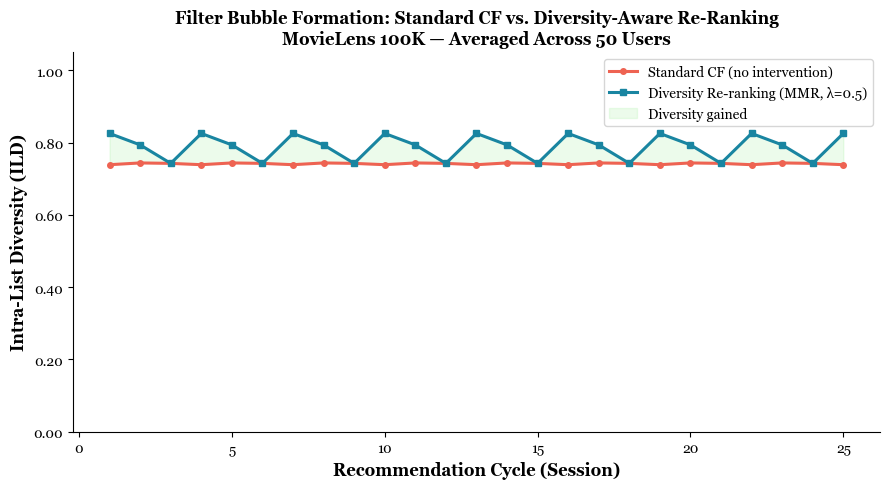

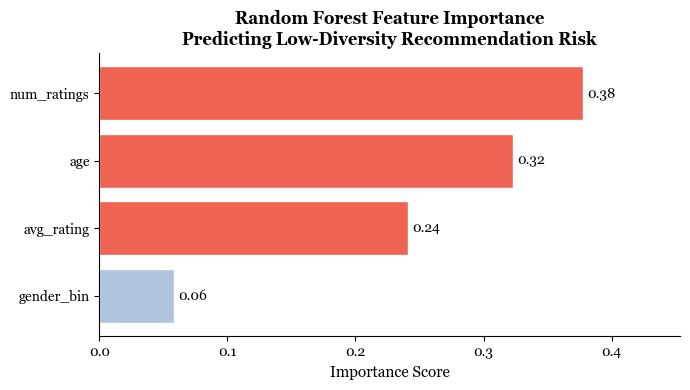

2026-03-31 20:15:06,680 | INFO | Both charts saved.


In [12]:
try:
    avg_by_cycle = results_df.groupby('cycle')[['cf_ild','diverse_ild']].mean()
    cycles   = avg_by_cycle.index.tolist()
    cf_ilds  = avg_by_cycle['cf_ild'].tolist()
    div_ilds = avg_by_cycle['diverse_ild'].tolist()

    #  Chart 1: ILD over cycles 
    fig1, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(cycles, cf_ilds,  color='#EE6352',    lw=2.2, marker='o', ms=4,
             label='Standard CF (no intervention)')
    ax1.plot(cycles, div_ilds, color='#1985A1', lw=2.2, marker='s', ms=4,
             label='Diversity Re-ranking (MMR, λ=0.5)')
    ax1.fill_between(cycles, cf_ilds, div_ilds, alpha=0.15, color='#81E979',
                     label='Diversity gained')
    # Labeling:
    ax1.set_xlabel('Recommendation Cycle (Session)', fontsize=12, weight = 'bold') 
    ax1.set_ylabel('Intra-List Diversity (ILD)', fontsize=12, weight = 'bold')
    ax1.set_title('Filter Bubble Formation: Standard CF vs. Diversity-Aware Re-Ranking\n'
                  'MovieLens 100K — Averaged Across 50 Users', fontsize=12, fontweight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax1.legend(fontsize=10)
    # Removing spines for a cleaner look:
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    plt.tight_layout()
    # Saving chart in 'pipeline' directory
    plt.savefig('pipeline/ild_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ----

    #  Chart 2: Feature importance 
    fig2, ax2 = plt.subplots(figsize=(7, 4))
    importances = pd.Series(clf.feature_importances_, index=features).sort_values()
    colors = ['#EE6352' if v > 0.1 else 'lightsteelblue' for v in importances] # if the importance is above 0.1, color it red, otherwise light blue
    bars = ax2.barh(importances.index, importances.values, color=colors, edgecolor='white')
    ax2.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    # labeling:
    ax2.set_title('Random Forest Feature Importance\n'
                  'Predicting Low-Diversity Recommendation Risk', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Importance Score', fontsize=11)
    ax2.set_xlim(0, importances.max() * 1.2)
    # Removing spines again for cleaner look:
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    plt.tight_layout()
    # Saving chart in 'pipeline' directory
    plt.savefig('pipeline/feature_importance_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

    log.info("Both charts saved.")
except Exception as e:
    log.error(f"Visualization error: {e}")
    raise

## Results Summary

In [13]:
print("FILTER BUBBLE SIMULATION RESULTS")

print(f"Dataset:          MovieLens 100K")
print(f"Users simulated:  {len(TARGET_USERS)}")
print(f"Cycles per user:  {N_CYCLES}")
print(f"List size (top-N): {TOP_N}")
print()
print(f"Average ILD — Standard CF:         {np.mean(cf_ilds):.4f}")
print(f"Average ILD — MMR Re-ranking:      {np.mean(div_ilds):.4f}")
print(f"Average diversity gain:            {np.mean(div_ilds) - np.mean(cf_ilds):.4f}")
print()
print(f"ILD at cycle  1 (CF vs MMR):  {cf_ilds[0]:.3f} vs {div_ilds[0]:.3f}")
print(f"ILD at cycle 25 (CF vs MMR):  {cf_ilds[-1]:.3f} vs {div_ilds[-1]:.3f}")
print()
print(f"RF Classifier Accuracy:  {acc:.3f}")

log.info("Pipeline finished.")


FILTER BUBBLE SIMULATION RESULTS
Dataset:          MovieLens 100K
Users simulated:  50
Cycles per user:  25
List size (top-N): 10

Average ILD — Standard CF:         0.7414
Average ILD — MMR Re-ranking:      0.7884
Average diversity gain:            0.0471

ILD at cycle  1 (CF vs MMR):  0.739 vs 0.825
ILD at cycle 25 (CF vs MMR):  0.739 vs 0.825

RF Classifier Accuracy:  0.500
2026-03-31 20:15:06,684 | INFO | Pipeline finished.
